# Approximate Nearest Neighbor Search

In this notebook, we'll try 'rolling our own' search functions, working with real data from the Intaka dataset.

In [1]:
# Install hoplite and TF 2.20
!pip install git+https://github.com/google-research/perch-hoplite.git
!pip install tensorflow~=2.20.0


  Cloning https://github.com/google-research/perch-hoplite.git to /tmp/pip-req-build-2yg6j_uf
  Running command git clone --filter=blob:none --quiet https://github.com/google-research/perch-hoplite.git /tmp/pip-req-build-2yg6j_uf
  Resolved https://github.com/google-research/perch-hoplite.git to commit b075df9dfe2eedbaebfd3e97a52b4cffe3569fe2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.5/14.5 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 2.8 MB/s eta 0:00:00
   ━━━

In [2]:
#@title Copy the database locally. { vertical-output: true }

from etils import epath
import os
intaka_path = epath.Path('gs://chirp-public-bucket/soundscapes/intaka')

# Copy the hoplite database to the Colab local storage.
# The usearch.index file is 3.6Gb, so takes a couple minutes to download.
# Files are placed in `/content` directory.
for fp in intaka_path.glob('hoplite*'):
  print(fp)
  with fp.open('rb') as f:
    with open(fp.name, 'wb') as g:
      g.write(f.read())
with (intaka_path / 'usearch.index').open('rb') as f:
  print(intaka_path / 'usearch.index')
  with open('usearch.index', 'wb') as g:
    %time g.write(f.read())



gs://chirp-public-bucket/soundscapes/intaka/hoplite.sqlite
gs://chirp-public-bucket/soundscapes/intaka/hoplite.sqlite-shm
gs://chirp-public-bucket/soundscapes/intaka/hoplite.sqlite-wal
gs://chirp-public-bucket/soundscapes/intaka/usearch.index
CPU times: user 15.2 s, sys: 19.9 s, total: 35.1 s
Wall time: 8min 34s


In [3]:
#@title Connect to the database. { vertical-output: true }
import os

from matplotlib import pyplot as plt
import numpy as np

from perch_hoplite.agile import audio_loader
from perch_hoplite.agile import classifier
from perch_hoplite.agile import classifier_data
from perch_hoplite.agile import embedding_display
from perch_hoplite.agile import source_info
from perch_hoplite.db  import brutalism
from perch_hoplite.db import score_functions
from perch_hoplite.db  import search_results
from perch_hoplite.db import sqlite_usearch_impl
from perch_hoplite.zoo import model_configs

db_path = '/content'  #@param {type:'string'}
#@markdown Identifier (eg, name) to attach to labels produced during validation.
annotator_id = 'aimeloick'  #@param {type:'string'}

db = sqlite_usearch_impl.SQLiteUsearchDB.create(db_path)
# Update the DB with some override values...
# Need to use the perch_v2_cpu model, and point the db to the google cloud
# bucket containing the data.
model_cfg = db.get_metadata('model_config')
model_cfg.model_config.tfhub_path = 'google/bird-vocalization-classifier/tensorFlow2/perch_v2_cpu'
model_cfg.model_config.tfhub_version = 1
db.insert_metadata('model_config', model_cfg)

sources_cfg = db.get_metadata('audio_sources')
sources_cfg.audio_globs[0]['base_path'] = 'gs://chirp-public-bucket/soundscapes/intaka'
db.insert_metadata('audio_sources', sources_cfg)
db.commit()

db_model_config = db.get_metadata('model_config')
embed_config = db.get_metadata('audio_sources')
model_class = model_configs.get_model_class(db_model_config.model_key)
embedding_model = model_class.from_config(db_model_config.model_config)
audio_sources = source_info.AudioSources.from_config_dict(embed_config)
if hasattr(embedding_model, 'window_size_s'):
  window_size_s = embedding_model.window_size_s
else:
  window_size_s = 5.0
audio_filepath_loader = audio_loader.make_filepath_loader(
    audio_sources=audio_sources,
    window_size_s=window_size_s,
    sample_rate_hz=embedding_model.sample_rate,
)

In [4]:
# YOUR CODE GOES HERE
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Let's warm up by making some simple interactions...
# Consult the database API in the hoplite repository to finish these.
# https://github.com/google-research/perch-hoplite/blob/main/perch_hoplite/db/interface.py

# 1) Print the number of embeddings in the database.
all_ids = db.get_embedding_ids()
count = db.count_embeddings()

print(f"Number of embeddings is {len(all_ids)}")
# 2) Make a numpy array with a random set of 10,000 embeddings from the database.
subset_ixs = np.random.choice(all_ids, size=10_000)
# get_embeddingds
_, subset = db.get_embeddings(subset_ixs)


Number of embeddings is 1125507


In [5]:
# 3) Make a tSNE scatter plot of these 10k embeddings.
subset_TSNE = TSNE(n_components=2).fit_transform(subset)

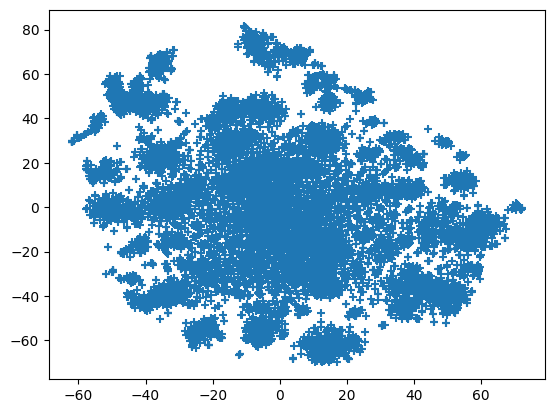

In [6]:
fig = plt.figure()
plt.scatter(subset_TSNE[:,0], subset_TSNE[:,1], marker='+')
plt.show()

In [7]:
# MY CODE GOES HERE
from perch_hoplite import audio_io
# Now let's try some brute-force search.

# 1) Get some audio from Xeno-Canto.
query_uri = 'xc878058' #@param
frame_rate = 100
sr = 32_000  #@param

# Load audio and sample rate
audio =  audio_io.load_xc_audio(query_uri, sr)



In [8]:
# 2) Use `embedding_model.embed` to get an embedding from the audio:
#    this is your query.
emb = embedding_model.embed(audio)
# Extract the embedding vector
query_embedding = emb.embeddings[0, 0]

print(f" Embedding shape: {query_embedding.shape}")


 Embedding shape: (1536,)


In [19]:
# 3) Find the 100 nearest neighbors in the database to the query, according
#    to whatever metric you like, using code you write yourself.

# How fast does your searhc run (ignoring the time to make the query)?

from time import time
from perch_hoplite.db import brutalism

start = time()
score_fn = np.dot
results, scores = brutalism.threaded_brute_search(db, query_embedding, 100, score_fn)
elapsed = time() - start
print(f"brutalism time is {elapsed} seconds")
top_100_ids = [int(result.embedding_id) for result in results.search_results[:100]]

# The raw_scores_array already contains the scores directly, so we can slice it.
top_100_scores = scores[:100]

print("First nearests IDs found:", top_100_ids[:5])
print("The scores corresponding:", top_100_scores[:5])

brutalism time is 14.608339786529541 seconds
First nearests IDs found: [205467, 602159, 563215, 375493, 767847]
The scores corresponding: [-0.03726798 -0.5094089  -0.13689998 -0.03689592 -0.09627785]


In [20]:
# Can you make it run faster?
# (Hint: numpy operations are fast, python operations are slow...)

# (Challenge: If you can search the database faster than
#  hoplite.db.brutalism.threaded_brute_search, you will get a cookie.)
k = 100
batch_size = 100
best_scores = np.full(k, -np.inf)
best_ids = np.full(k, -1)
query_embedding_norm = query_embedding

start = time()
for i in range(0, len(all_ids), batch_size):
    batch_ids = all_ids[i:i+batch_size]
    _, batch_embeddings = db.get_embeddings(batch_ids)
    batch_embeddings_norm = batch_embeddings
    scores = np.dot(batch_embeddings_norm, query_embedding_norm)

    combined_scores = np.concatenate([best_scores, scores])
    combined_ids = np.concatenate([best_ids, batch_ids])

    top_ixs = np.argpartition(-combined_scores, k)[:k]
    best_scores = combined_scores[top_ixs]
    best_ids = combined_ids[top_ixs]
elapsed = time() - start
# final tri
top_sorted = np.argsort(-best_scores)
best_scores = best_scores[top_sorted]
best_ids = best_ids[top_sorted]
print(f"Research time is {elapsed} seconds")
print("First nearests IDs found:", best_ids[:5])
print("The scores corresponding:", best_scores[:5])

Research time is 10.622436285018921 seconds
First nearests IDs found: [ 670401  692209 1119723   19524  910152]
The scores corresponding: [6.47407675 6.23106813 6.22793579 6.08937263 5.99935579]


In [18]:
# MY CODE GOES HERE
# Now let's try cluster-based search.
# 1) Cluster the audio in the database with K-Means.
# 2) Arrange the embedding data into clusters.
from sklearn.cluster import KMeans
from sklearn.cluster import MiniBatchKMeans
num_clusters = 50
kmeans = MiniBatchKMeans(
    n_clusters=num_clusters,
    batch_size=batch_size,
    random_state=0,
    n_init=10
)
for start in range(0, len(all_ids), batch_size):
    end = min(start + batch_size, len(all_ids))
    batch_ids = all_ids[start:end]
    _, batch_emb = db.get_embeddings(batch_ids)
    batch_emb = batch_emb.astype(np.float32)

    kmeans.partial_fit(batch_emb)
cluster_bins = {i: [] for i in range(num_clusters)}
centroids = kmeans.cluster_centers_
print("Centroids shape:", centroids.shape)

print("Assigning all embeddings to clusters...")
for start in range(0, len(all_ids), batch_size):
    end = min(start + batch_size, len(all_ids))
    batch_ids = all_ids[start:end]
    _, batch_emb = db.get_embeddings(batch_ids)
    batch_emb = batch_emb.astype(np.float32)

    labels = kmeans.predict(batch_emb)
    for i, cid in enumerate(labels):
        cluster_bins[cid].append(batch_ids[i])
print("Done.")

Centroids shape: (50, 1536)
Assigning all embeddings to clusters...
Done.


In [13]:
# 3) Write a function which uses these clusters and the cluster centroids
#    to search the data.
# 4) Check how long it takes to run. Is it faster than brute force search?
#    Can you make it faster?
def cluster_based_search(query_embedding, centroids, cluster_bins, k=100):
    q = query_embedding.astype(np.float32).squeeze()
    centroid_scores = np.dot(centroids, q)
    best_clusters = np.argsort(-centroid_scores)[:5]

    candidate_ids = []

    for cid in best_clusters:
        candidate_ids.extend(cluster_bins[cid])

    candidate_ids = np.array(candidate_ids)
    print(f"Searching among {len(candidate_ids)} candidates.")

    best_scores = []
    best_ids = []

    for start in range(0, len(candidate_ids), batch_size):
        end = min(start + batch_size, len(candidate_ids))
        batch_ids = candidate_ids[start:end]

        _, batch_emb = db.get_embeddings(batch_ids)
        batch_emb = batch_emb.astype(np.float32)

        scores = np.dot(batch_emb, q)

        top_ixs = np.argpartition(-scores, min(k, len(scores)-1))[:k]
        top_ixs = top_ixs[np.argsort(-scores[top_ixs])]

        best_ids.extend(batch_ids[top_ixs])
        best_scores.extend(scores[top_ixs])

    best_ids = np.array(best_ids)
    best_scores = np.array(best_scores)

    global_ixs = np.argsort(-best_scores)[:k]

    return best_ids[global_ixs], best_scores[global_ixs]


print("Running cluster-based search...")
start = time()
ids, scores = cluster_based_search(query_embedding, centroids, cluster_bins, k=100)
running = time() - start
print("Top 10 IDs:", ids[:10])
print("Top 10 scores:", scores[:10])
print(f"Runing time is {running} seconds")

Running cluster-based search...
Searching among 210694 candidates.
Top 10 IDs: [ 692209  519647 1045979  238546  691915  952013  279435  987709  578326
  205466]
Top 10 scores: [6.231068  5.954821  5.547022  5.2475615 4.6573153 4.5495663 4.546655
 4.534422  4.4702277 4.4324827]
Runing time is 2.1521215438842773 seconds


**Test on subset dataset**

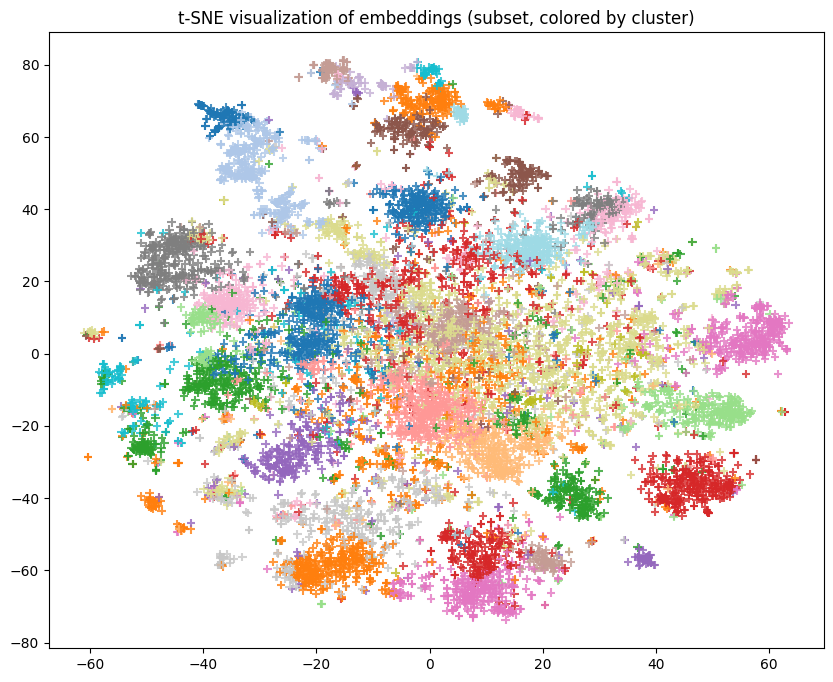

In [14]:
subset_clusters = kmeans.fit_predict(subset)

tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=0)
subset_TSNE = tsne.fit_transform(subset)

plt.figure(figsize=(10, 8))

plt.scatter(
    subset_TSNE[:, 0],
    subset_TSNE[:, 1],
    c=subset_clusters,
    cmap='tab20',
    marker='+',
    alpha=0.8
)

plt.title("t-SNE visualization of embeddings (subset, colored by cluster)")
plt.show()

In [15]:
# 5) What is the top-100 recall of your cluster-based search?
#    Use random embeddings from the database as queries.
num_queries = 20
query_ids = np.random.choice(all_ids, size=num_queries, replace=False)

cluster_times = []
bruteforce_times = []
recalls = []

for id in query_ids:
    _, query_embedding_for_search = db.get_embeddings([id])
    query_embedding_for_search = query_embedding_for_search.squeeze()

    start = time()
    cluster_ids, _ = cluster_based_search(query_embedding_for_search, centroids=centroids, k=k, cluster_bins=cluster_bins)
    cluster_elapsed = time() - start
    cluster_times.append(cluster_elapsed)

    start = time()
    bf_results_obj, _ = brutalism.threaded_brute_search(db, query_embedding_for_search, k, np.dot)
    bf_elapsed = time() - start
    bruteforce_times.append(bf_elapsed)

    bf_ids = [res.embedding_id for res in bf_results_obj.search_results]

    recall = len(set(cluster_ids) & set(bf_ids)) / k
    recalls.append(recall)

    print(f"Query {id}: cluster-time={cluster_elapsed:.3f}s, brute-force-time={bf_elapsed:.3f}s, recall={recall:.2f}")

print("\n=== Summary ===")
print(f"Average cluster-based search time: {np.mean(cluster_times):.3f}s")
print(f"Average brute-force search time: {np.mean(bruteforce_times):.3f}s")
print(f"Average top-100 recall: {np.mean(recalls):.3f}")

Searching among 98368 candidates.
Query 23036: cluster-time=0.873s, brute-force-time=13.119s, recall=0.98
Searching among 30443 candidates.
Query 422596: cluster-time=0.259s, brute-force-time=12.669s, recall=0.99
Searching among 120854 candidates.
Query 1121289: cluster-time=1.019s, brute-force-time=12.700s, recall=1.00
Searching among 146253 candidates.
Query 702251: cluster-time=1.249s, brute-force-time=12.470s, recall=0.99
Searching among 201975 candidates.
Query 876395: cluster-time=1.730s, brute-force-time=12.275s, recall=0.56
Searching among 154284 candidates.
Query 1051391: cluster-time=1.854s, brute-force-time=12.231s, recall=1.00
Searching among 168334 candidates.
Query 1042720: cluster-time=2.068s, brute-force-time=17.492s, recall=1.00
Searching among 148147 candidates.
Query 81523: cluster-time=1.271s, brute-force-time=13.053s, recall=0.99
Searching among 154284 candidates.
Query 1048743: cluster-time=1.323s, brute-force-time=13.630s, recall=0.98
Searching among 53038 candid